In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm, Normalize
import pdb 

from scipy.signal import find_peaks


In [2]:
NaI_files_unsorted = sorted(glob.glob("Hera Geant 4 Simulations/1e6_photon_sims/NaI*.out",recursive = True))
LgPl_files_unsorted = sorted(glob.glob("Hera Geant 4 Simulations/1e6_photon_sims/LgPl*.out",recursive = True))
simple_NaI_files_unsorted = sorted(glob.glob("Hera Geant 4 Simulations/simple_mass_model-build/NaI*.out",recursive = True))
simple_LgPl_files_unsorted = sorted(glob.glob("Hera Geant 4 Simulations/simple_mass_model-build/LgPl*.out",recursive = True))
#NaI_files_unsorted = sorted(glob.glob("/home/enp/geant4/simulations/ADOTR_mass_model-build/NaI*.out",recursive = True))
#LgPl_files_unsorted = sorted(glob.glob("/home/enp/geant4/simulations/ADOTR_mass_model-build/LgPl*.out",recursive = True))

#sorts the geant4 output files into sequential energy order
def sort_files(files):
    sorted_files = []
    for i in range(0,58):
        sorted_files.append(files[i])
    for i in range(73,81):
        sorted_files.append(files[i])
    for i in range(91,96):
        sorted_files.append(files[i])
    for i in range(106,111):
        sorted_files.append(files[i])
    for i in range(112,129):
        sorted_files.append(files[i]) 
    for i in range(58,73):
        sorted_files.append(files[i])
    for i in range(81,91):
        sorted_files.append(files[i])
    for i in range(96,106):
        sorted_files.append(files[i])
    sorted_files.append(files[111])
    return sorted_files


#Geant4 mono-energy response output files in sequential energy order
NaI_files = sort_files(NaI_files_unsorted)
LgPl_files = sort_files(LgPl_files_unsorted)
simple_NaI_files = sort_files(simple_NaI_files_unsorted)
simple_LgPl_files = sort_files(simple_LgPl_files_unsorted)

#TGF spectrums
TGF_file = "Hera Geant 4 Simulations/Dwyer_REAM_files/6km_downward_TGF/joeAltdown_6.txt"
#TGF_file_reverse = "/home/enp/geant4/simulations/Dwyer_REAM_files/6km_downward_TGF/joeAltdown_reverseonly_6.txt"


#Geant output for both 2x2 NaI and 2x2x12 plastic 
#energy deposits from an incident TGF spectrum (no atmospheric transport)  
file = 'Hera Geant 4 Simulations/joespec_hera2.out'
binlow = (np.loadtxt(file,max_rows=10000,usecols=(0),dtype=float))/1e3
countsnai = np.loadtxt(file,max_rows=10000,usecols=(3),dtype=float)
countspla = np.loadtxt(file,max_rows=10000,usecols=(2),dtype=float)

#pla_2d_array = np.column_stack((binlow,countspla))
#np.savetxt('david_geant_LgPl_Response',pla_2d_array)

###### Mass Model Functions ############

#reads in the geant4 mass model simulation files
def readfile(file):
    events = np.loadtxt(file,skiprows=1,usecols=(1),dtype=float)
    events = events/1e6 #make units MeV
    return events

#cuts off a lower limit of energies of mass model files
def energyFilter(file):
    events = readfile(file)
    events = events[events > 0.005] #cuts out energies less than 300keV
    #events = events[events < 10.0] #cuts out energies greater than 10MeV
    return events

#makes a histogram of a mass model file
def histOut(file):
    events = energyFilter(file)
    hist, binEdge = np.histogram(events, bins = binenergies) 
    return hist, binEdge
 
#runs through all the mass model files and makes a matrix of histograms    
def Matrixer(filelist):
    matrix = []
    binEdges= []
    for file in filelist:
        hist, binEdge = histOut(file)
        matrix.append(hist)
        binEdges.append(binEdge)
    return matrix, binEdges

#runs through all the mass model files and creates a array of all the energy deposition events (used in visualization)    
def EnergyList(fileList):
    E_dep = []
    for file in fileList:
        events = energyFilter(file)
        E_dep.append(events)
    return E_dep

###### TGF Spectrum Functions ########

#reads in an example TGF file (list of energies)
def TGF_Reader(file):
    gammalist = np.loadtxt(file)
    TGF_energy = gammalist[0:,0] #MeV
    #TGF_energy.fill(0.662) #to simulate a monoenergetic source of Cs137
    ZenithRad = gammalist[0:,2]
    ZenithDeg = ZenithRad * 180./np.pi
    return TGF_energy, ZenithDeg

def TGF_Filter(file):
    events, degrees = TGF_Reader(file)
    #events = np.delete(events,np.where(degrees<160.))
    #events = events[events > 0.005] #cuts out energies less than 10keV
    return events

#creates the TGF spectrum binned the same as the response matrix 
def TGF_spectrum(file):
    events = TGF_Filter(file)
    hist, binEdge = np.histogram(events, bins = binenergies)
    return hist
    

def ResponseSpectrum(file, matrix):
    TGF_Spectrum = TGF_spectrum(file)
    #TGF_diff = 1/binCenters * np.exp(-binCenters/7.3)
    #TGF_Spectrum = TGF_diff*binWidths
    output = TGF_Spectrum * 0
    #pdb.set_trace()
    for i in np.arange(len(matrix)):
        output = output + (matrix[i]*TGF_Spectrum[i])
    return output


sequential_input_energies = np.array([0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
                              0.1,0.110,0.120,0.130,0.140,0.150,0.160,0.170,0.18,0.19,0.2,0.21,0.22,0.23,0.24,0.253,0.27,
                              0.29,0.31,0.33,0.35,0.37,0.39,0.41,0.43,0.45,0.47,0.49,0.51,0.53,0.557,0.6,0.65,0.7,0.75,0.8,
                              0.85,0.9,0.95,1.012,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.,2.1,2.2,2.3,2.4,2.525,2.7,2.9,3.1,
                              3.3,3.5,3.7,3.9,4.1,4.3,4.5,4.7,4.9,5.1,5.3,5.5,5.70,5.9,6.1,6.3,6.5,6.7,6.9,7.1,7.3,7.575,8.,
                              8.5,9.,9.5,10.,10.5,11.0,11.5,12.,12.5,13.,13.5,14.,14.5,15.12,16.,17.,18.,19.,20.,21.,22.,23.,
                              24.,25.,26.,27.,28.,29.,30.,31.,32.,33.,34.,35.,36.,37.,38.,39.,40.]) #MeV

binenergies = np.array([0.005,0.015,0.025,0.035,0.045,0.055,0.065,0.075,0.085,
                        0.095, 0.105, 0.115, 0.125, 0.135, 0.145, 0.155, 0.165, 0.175, 0.185, 
                        0.195, 0.205, 0.215, 0.225, 0.235, 0.245, 0.260, 0.280, 0.300, 0.320, 
                        0.340, 0.360, 0.380, 0.400, 0.420, 0.440, 0.460, 0.480, 0.500, 0.520, 
                        0.540, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875, 0.925, 0.975, 
                        1.050, 1.150, 1.250, 1.350, 1.450, 1.550, 1.650, 1.750, 1.850, 1.950, 
                        2.050, 2.150, 2.250, 2.350, 2.450, 2.600, 2.800, 3.000, 3.200, 3.400, 
                        3.600, 3.800, 4.000, 4.200, 4.400, 4.600, 4.800, 5.000, 5.200, 5.400,
                        5.600, 5.800, 6.000, 6.200, 6.400, 6.600, 6.800, 7.000, 7.200, 7.400, 
                        7.750, 8.250, 8.750, 9.250, 9.750, 10.250, 10.750, 11.250, 11.750, 
                        12.250, 12.750, 13.250, 13.750, 14.250, 14.750, 15.500, 16.500, 17.500, 
                        18.500, 19.500, 20.500, 21.500, 22.500, 23.500, 24.500, 25.500, 26.500, 
                        27.500, 28.500, 29.500, 30.500, 31.500, 32.500, 33.500, 34.500, 35.500, 
                        36.500, 37.500, 38.500, 39.500, 40.500]) #MeV

binWidths = (binenergies - np.roll(binenergies,1))[1:]
binCenters = (binenergies + np.roll(binenergies,1))[1:]/2

print('GEANT4 input energies shape:           ', sequential_input_energies.shape)
print('GEANT4 results energy bins shape:      ', binenergies.shape)
print('GEANT4 results energy binwidths shape: ', binWidths.shape)
print('GEANT4 results energy bincenters shape:', binCenters.shape)


GEANT4 input energies shape:            (129,)
GEANT4 results energy bins shape:       (130,)
GEANT4 results energy binwidths shape:  (129,)
GEANT4 results energy bincenters shape: (129,)


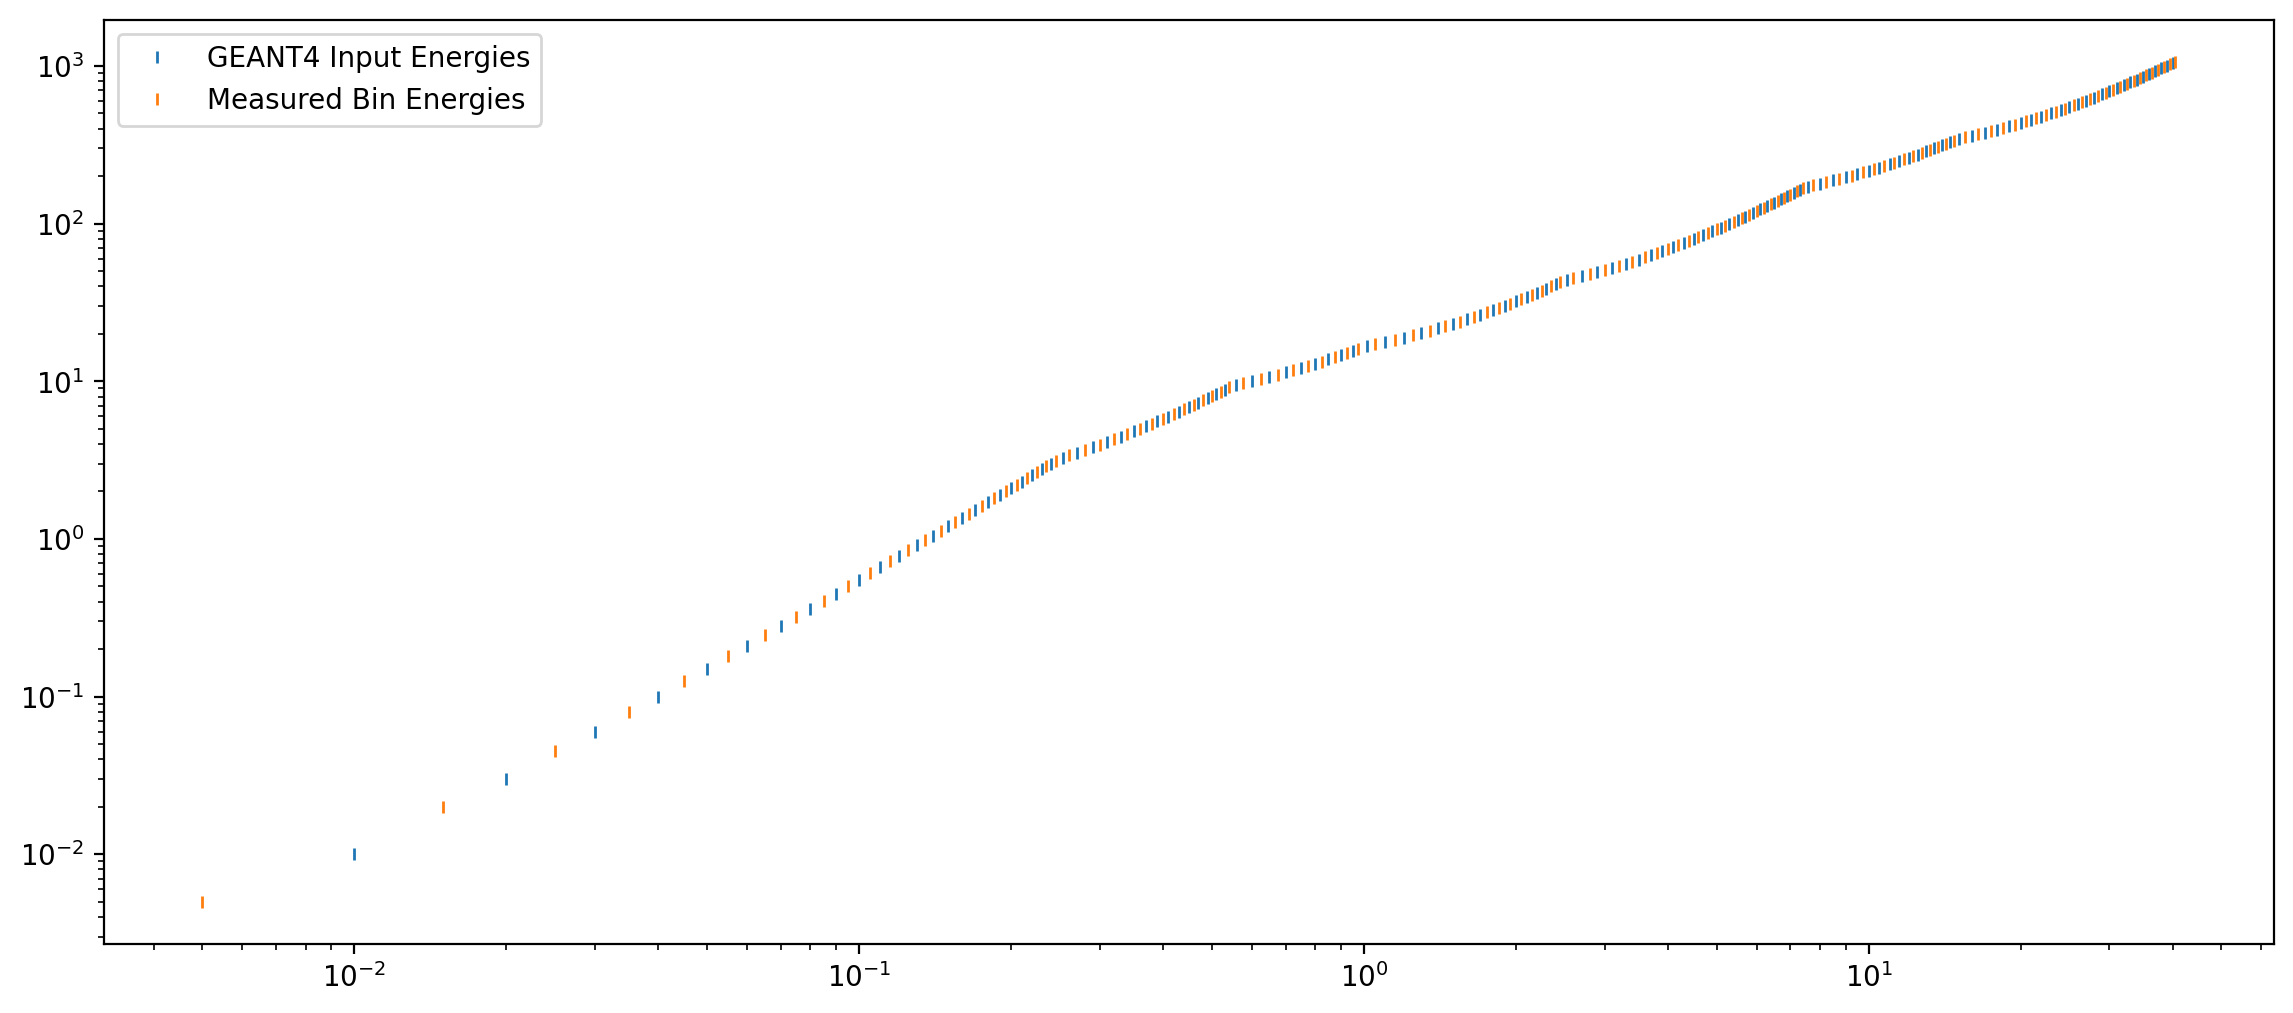

In [3]:
plt.figure(figsize=(14,6), dpi=200)
plt.plot(sequential_input_energies, np.cumsum(sequential_input_energies), marker='|', linestyle='', markersize=4, label='GEANT4 Input Energies')
plt.plot(binenergies, np.cumsum(binenergies), marker='|', linestyle='', markersize=4, label='Measured Bin Energies')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [4]:

NaI_matrix, NaI_binedges = Matrixer(NaI_files)
LgPl_matrix, LgPl_binedges = Matrixer(LgPl_files)

simple_NaI_matrix, simple_NaI_binedges = Matrixer(simple_NaI_files)
simple_LgPl_matrix, simple_LgPl_binedges = Matrixer(simple_LgPl_files)
print('simple_NaI_matrix', np.array(simple_NaI_matrix).shape)
print('simple_LgPl_matrix', np.array(simple_LgPl_matrix).shape)

TGF_Spectrum = TGF_spectrum(TGF_file)/binWidths
#TGF_Spectrum = TGF_diff
NaIResponse = ResponseSpectrum(TGF_file, NaI_matrix)/binWidths
LgPlResponse = ResponseSpectrum(TGF_file, LgPl_matrix)/binWidths
print('NaIResponse', np.array(NaIResponse).shape)
print('LgPlResponse', np.array(LgPlResponse).shape)

simple_NaIResponse = ResponseSpectrum(TGF_file, simple_NaI_matrix)/binWidths
simple_LgPlResponse = ResponseSpectrum(TGF_file, simple_LgPl_matrix)/binWidths
print('simple_NaIResponse', np.array(simple_NaIResponse).shape)
print('simple_LgPlResponse', np.array(simple_LgPlResponse).shape)

/tmp/ipykernel_68836/4091446318.py:56: UserWarning: loadtxt: input contained no data: "Hera Geant 4 Simulations/1e6_photon_sims/NaI_0.010MeV_Events.out"
  events = np.loadtxt(file,skiprows=1,usecols=(1),dtype=float)
/tmp/ipykernel_68836/4091446318.py:56: UserWarning: loadtxt: input contained no data: "Hera Geant 4 Simulations/1e6_photon_sims/NaI_0.020MeV_Events.out"
  events = np.loadtxt(file,skiprows=1,usecols=(1),dtype=float)
/tmp/ipykernel_68836/4091446318.py:56: UserWarning: loadtxt: input contained no data: "Hera Geant 4 Simulations/1e6_photon_sims/NaI_0.030MeV_Events.out"
  events = np.loadtxt(file,skiprows=1,usecols=(1),dtype=float)
/tmp/ipykernel_68836/4091446318.py:56: UserWarning: loadtxt: input contained no data: "Hera Geant 4 Simulations/1e6_photon_sims/LgPl_0.010MeV_Events.out"
  events = np.loadtxt(file,skiprows=1,usecols=(1),dtype=float)
/tmp/ipykernel_68836/4091446318.py:56: UserWarning: loadtxt: input contained no data: "Hera Geant 4 Simulations/1e6_photon_sims/LgPl_0.

simple_NaI_matrix (129, 129)
simple_LgPl_matrix (129, 129)
NaIResponse (129,)
LgPlResponse (129,)
simple_NaIResponse (129,)
simple_LgPlResponse (129,)


Dwyer Peak: 0.49 MeV @ bincenters[36]


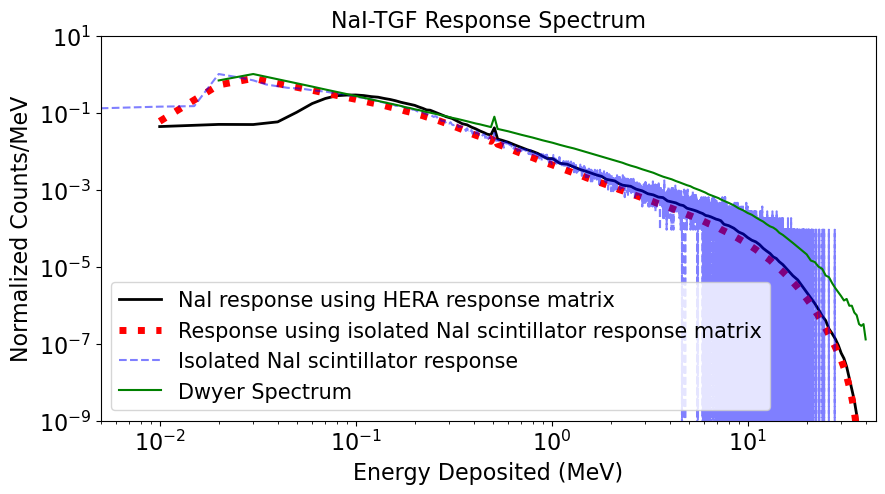

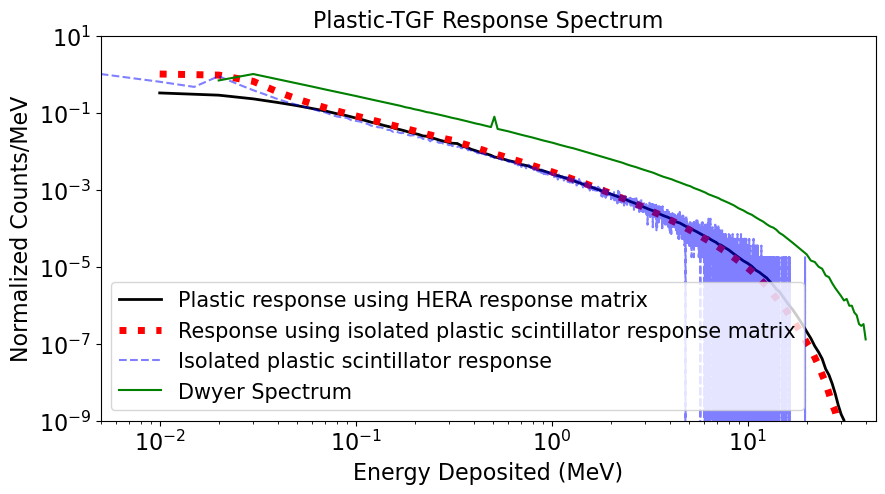

In [5]:
plt.figure(figsize=(10,5)) #/max(NaIResponse)/3.5
plt.plot(binCenters, NaIResponse/max(NaIResponse)/3.5, color='black',linestyle='-',linewidth=2,label='NaI response using HERA response matrix')
plt.plot(binCenters, simple_NaIResponse/max(simple_NaIResponse)/1.3,linestyle='dotted',linewidth=5,color='red',label='Response using isolated NaI scintillator response matrix')
plt.plot(binlow, countsnai/max(countsnai),color='blue',alpha=.5,linestyle='--',label='Isolated NaI scintillator response')
# plt.plot(binCenters[1:], TGF_Spectrum[1:]/max(TGF_Spectrum)/1.4, color = 'green', label='Dwyer Spectrum')
plt.plot(binCenters[1:], TGF_Spectrum[1:]/max(TGF_Spectrum), color = 'green', label='Dwyer Spectrum')
plt.xlim(.005,45)
plt.ylim(1e-9,10)
plt.yscale("log")
plt.xscale("log") #'m running singularity on an HPC cluster. I want to have an isolated environment so I can do development without affecting my home directory.
plt.title("NaI-TGF Response Spectrum",fontsize=16)
plt.ylabel("Normalized Counts/MeV",fontsize=16)
plt.xlabel("Energy Deposited (MeV)",fontsize=16)
plt.tick_params(labelsize=16)
plt.legend(loc=3,fontsize=15)

plt.figure(figsize=(10,5))
plt.plot(binCenters, LgPlResponse/max(LgPlResponse)/3.1, color='black',linewidth=2,label='Plastic response using HERA response matrix')
plt.plot(binCenters, simple_LgPlResponse/max(simple_LgPlResponse), color='red',linestyle='dotted',linewidth=5,label='Response using isolated plastic scintillator response matrix')
plt.plot(binlow, countspla/max(countspla),color='blue',alpha=.5,linestyle='--',label='Isolated plastic scintillator response')
# plt.plot(binCenters[1:], TGF_Spectrum[1:]/max(TGF_Spectrum)/2.5, color = 'green', label='Dwyer Spectrum')
plt.plot(binCenters[1:], TGF_Spectrum[1:]/max(TGF_Spectrum), color = 'green', label='Dwyer Spectrum')
plt.xlim(.005,45)
plt.ylim(1e-9,10)
#plt.ylim(1e-8,10)
plt.yscale("log")
plt.xscale("log")
plt.title("Plastic-TGF Response Spectrum",fontsize=16)
plt.ylabel("Normalized Counts/MeV",fontsize=16)
plt.xlabel("Energy Deposited (MeV)",fontsize=16)
plt.tick_params(labelsize=16)
plt.legend(loc=3,fontsize=15)

arg_pair_prod_peak = find_peaks(np.log(TGF_Spectrum[1:]/max(TGF_Spectrum)), prominence=.5)[0][0]
print('Dwyer Peak: {} MeV @ bincenters[{}]'.format(binCenters[arg_pair_prod_peak], arg_pair_prod_peak))

(129, 129)


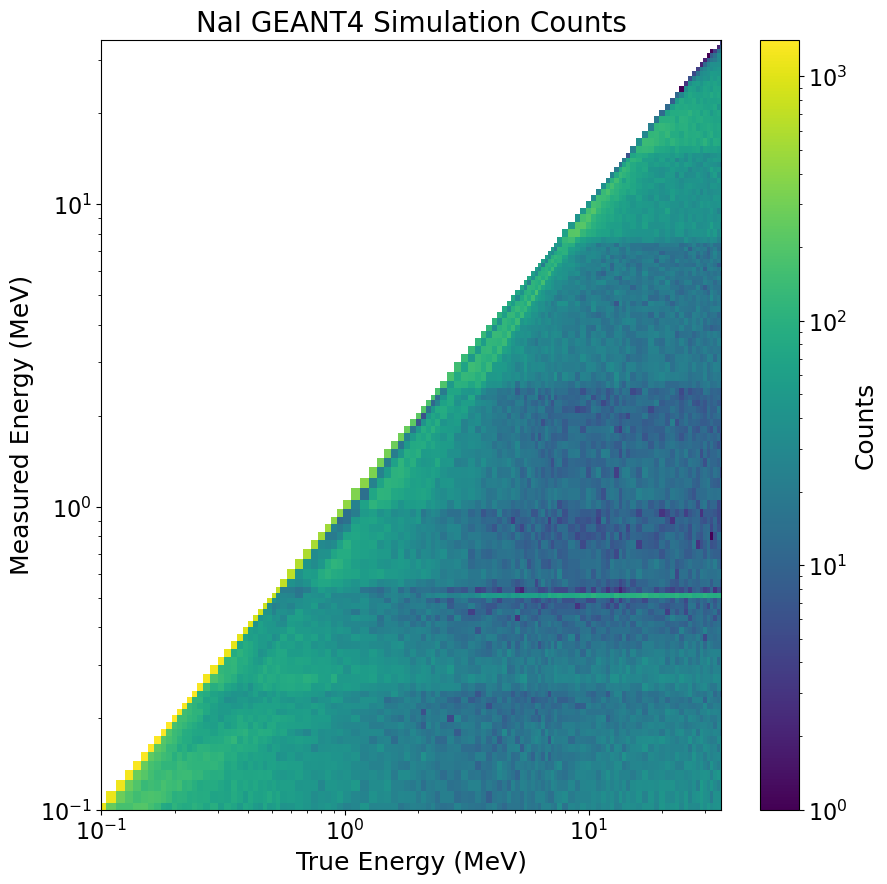

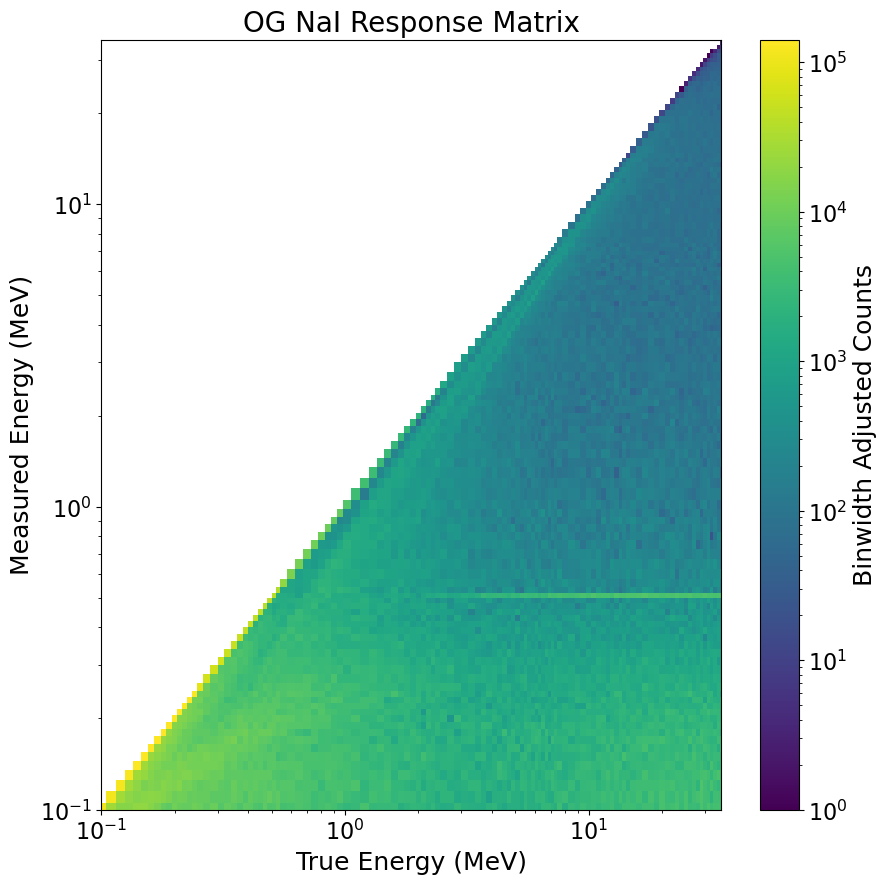

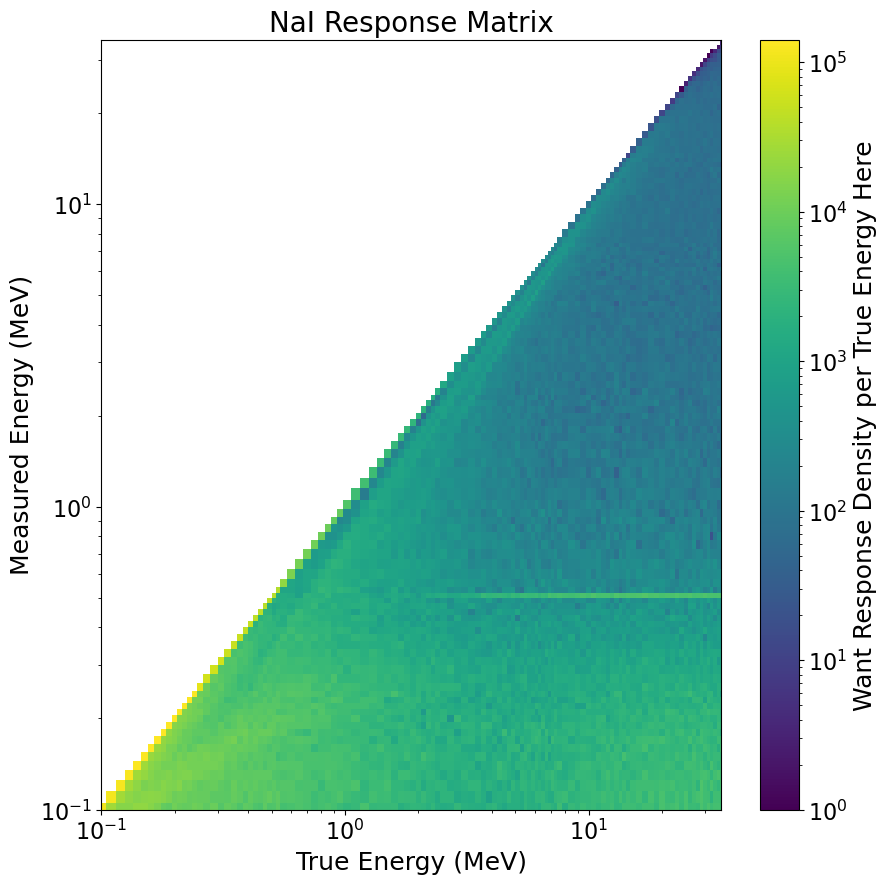

In [6]:
cmap_color = 'viridis'
shading = 'auto'
plt.figure(figsize=(10,10))
NaI_matrix = np.array(NaI_matrix)
plt.pcolormesh(sequential_input_energies, binCenters, (NaI_matrix).T,
               shading=shading, cmap=cmap_color,
               # norm=LogNorm(vmin=1E-5, vmax=1E0),
               norm=LogNorm(),
               )

cb = plt.colorbar()
cb.ax.tick_params(labelsize=16)
cb.set_label(label='Counts', size=18)
plt.xlim(.1,35)
plt.ylim(.1,35)
plt.xscale('log')
plt.yscale('log')
plt.title('NaI GEANT4 Simulation Counts',fontsize=20)
plt.xlabel('True Energy (MeV)',fontsize=18)
plt.ylabel('Measured Energy (MeV)',fontsize=18)
plt.tick_params(labelsize=16)


cmap_color = 'viridis'
shading = 'auto'
plt.figure(figsize=(10,10))
NaI_matrix = np.array(NaI_matrix)
plt.pcolormesh(sequential_input_energies, binCenters, (NaI_matrix/binWidths).T,
               shading=shading, cmap=cmap_color,
               # norm=LogNorm(vmin=1E-5, vmax=1E0),
               norm=LogNorm(),
               )
cb = plt.colorbar()
cb.ax.tick_params(labelsize=16)
cb.set_label(label='Binwidth Adjusted Counts', size=18)
plt.xlim(.1,35)
plt.ylim(.1,35)
plt.xscale('log')
plt.yscale('log')
plt.title('OG NaI Response Matrix',fontsize=20)
plt.xlabel('True Energy (MeV)',fontsize=18)
plt.ylabel('Measured Energy (MeV)',fontsize=18)
plt.tick_params(labelsize=16)


# NaI Density Matrix
NaI_matrix = np.array(NaI_matrix)
print(NaI_matrix.shape)
NaI_response_density_matrix = NaI_matrix.copy().astype(np.double) # so we can comment/uncomment other lines
# NaI_response_density_matrix /= np.max(NaI_response_density_matrix, axis=1) # before or after bin width correction. Is this even correct? See notes below
NaI_response_density_matrix /= binWidths[None,:] # This gives smooth output, showing that binwidths should be divided on axis=1

# visually show correct axis 1 is vertical
# NaI_response_density_matrix[binWidths.size//2, :] = 1000 * np.ones(binWidths.size)

cmap_color = 'viridis'
shading = 'auto'
plt.figure(figsize=(10,10))
plt.pcolormesh(sequential_input_energies, binCenters, (NaI_response_density_matrix).T,
               shading=shading, cmap=cmap_color,
               norm=LogNorm(),
               )
cb = plt.colorbar()
cb.ax.tick_params(labelsize=16)
cb.set_label(label='Want Response Density per True Energy Here', size=18)
plt.xlim(.1,35)
plt.ylim(.1,35)
plt.xscale('log')
plt.yscale('log')
plt.title('NaI Response Matrix',fontsize=20)
plt.xlabel('True Energy (MeV)',fontsize=18)
plt.ylabel('Measured Energy (MeV)',fontsize=18)
plt.tick_params(labelsize=16)


/tmp/ipykernel_68836/3968172035.py:8: RuntimeWarning: invalid value encountered in divide
  photo_fraction = np.diag(cleaned)/np.sum(cleaned, axis=1)


(array([0, 1, 2]),)
(array([0, 1, 2]),)


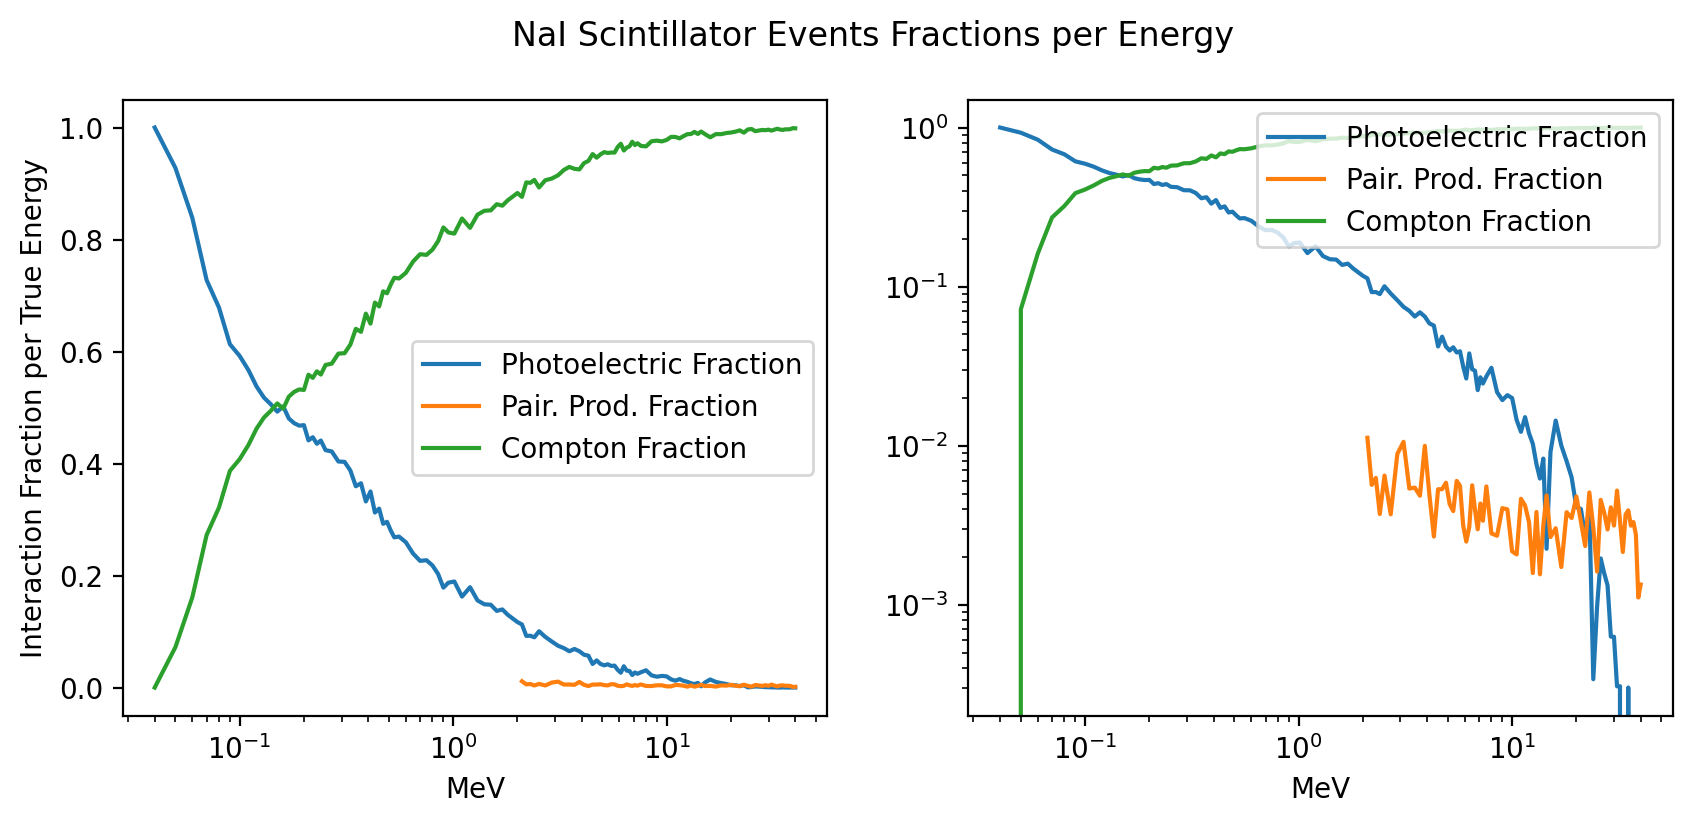

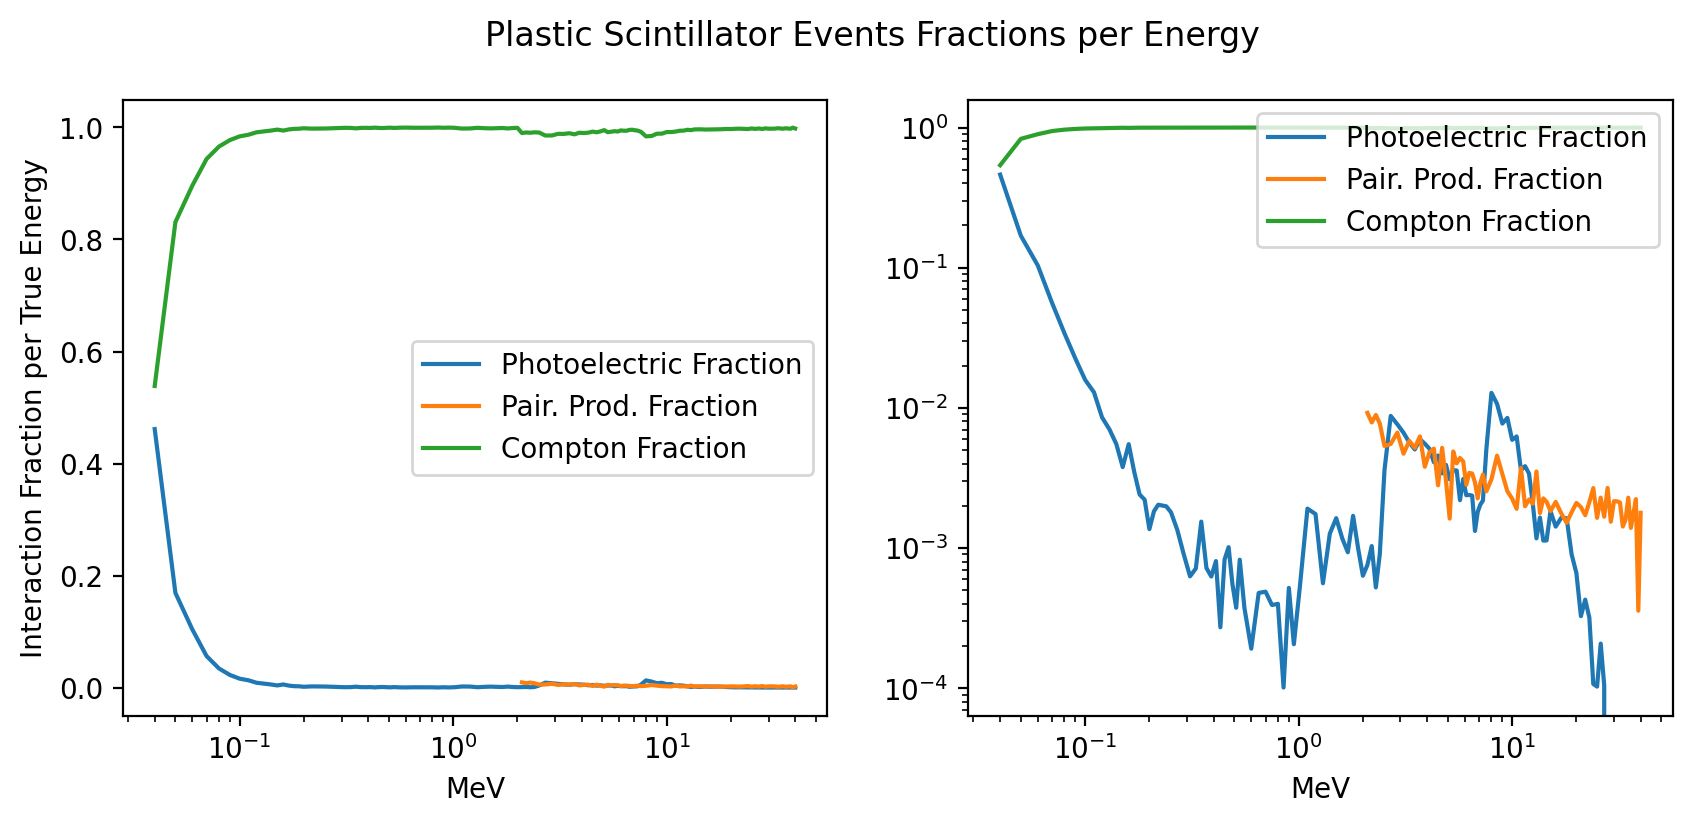

In [7]:
for scintillator, matrix in zip(['NaI','Plastic'], [NaI_matrix, LgPl_matrix]):
    matrix = np.array(matrix)

    #Photoelectric Effect
    cleaned = matrix.copy()
    cleaned[np.isnan(cleaned)] = 0
    cleaned[np.isinf(cleaned)] = 0
    photo_fraction = np.diag(cleaned)/np.sum(cleaned, axis=1)
    print(np.where(np.isnan(photo_fraction)))
    
    # Pair Production
    # mask = binCenters > binCenters[arg_pair_prod_peak]
    # pair_fraction = (matrix[:, arg_pair_prod_peak]/np.sum(matrix, axis=1))[arg_pair_prod_peak+1:]
    mask = binCenters > 2 # MeV
    pair_fraction = (cleaned[mask, arg_pair_prod_peak]/np.sum(cleaned[mask,:], axis=1))
    
    # Compton Scattering
    compton_fraction = np.ones_like(binCenters)
    compton_fraction -= photo_fraction
    compton_fraction[mask] -= pair_fraction
    
    fig, axes = plt.subplots(1,2, figsize=(10,4), dpi=200)
    axes[0].plot(binCenters, photo_fraction, label='Photoelectric Fraction')
    axes[0].plot(binCenters[mask], pair_fraction, label='Pair. Prod. Fraction')
    axes[0].plot(binCenters, compton_fraction, label='Compton Fraction')
    
    axes[0].set_xscale('log')
    axes[0].set_xlabel('MeV')
    axes[0].set_ylabel('Interaction Fraction per True Energy')
    axes[0].legend()
    
    axes[1].plot(binCenters, photo_fraction, label='Photoelectric Fraction')
    axes[1].plot(binCenters[mask], pair_fraction, label='Pair. Prod. Fraction')
    axes[1].plot(binCenters, compton_fraction, label='Compton Fraction')
    
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('MeV')
    axes[1].legend(loc='upper right')
    fig.suptitle('{} Scintillator Events Fractions per Energy'.format(scintillator))

In [8]:
# TODO want to-rework this with numpy-units to make sure we are plotting with discipline.
# Need to re-make exisiting plots with units involved in math. When plotting distributions, do we need to normalize out both x and y axis?
# What currently as of 06/20 seems wrong visually. By dividing out bin width... we are making local density >> 1. While not incorrect mathemtically for a
# probability density function, it is wrong for a discrete distribution. Since we are representing a discrete pdf... does that make it wrong?
# Should we be dividing by bin widths on one axis and "sequential energy input widths" on the other? NO! Becase the input was not a distribution, but a set of simualtions for each input energy

# TODO also note we could change the bins we use!! Maybe that would be helpful. Evenly logspaced bins? Advantage of current method is captures relevant features well.
# binenergies... sequential_input_energies referes to geant4 input bins. That is a fixed input here without a lot of work.

# Notes: 
#    -In linear space, PMFs and PDFs should integrate/sum to one. PMF values should be <= 1. PDF values can be > 1. We are representing a PDF with discrete bins,
#     so it's ok for values in dist > 1 for density.
#    -We should NOT assume that the measured energy is a distribution, AS IS. We have cut off a subset of events (which may not be detectable) but are technically still there.
#        

# Also we are not accounting on this plot for the possibility we measure energies below the threshold of the minimum inputs... (of course in the HERA sensors, there is a minum we can detect due to voltage cutoff. 1 bit of resolution? What is that energy?)

# What is the distribution of photoelectric peak, compton scatters, and pair production peak across spectrums?

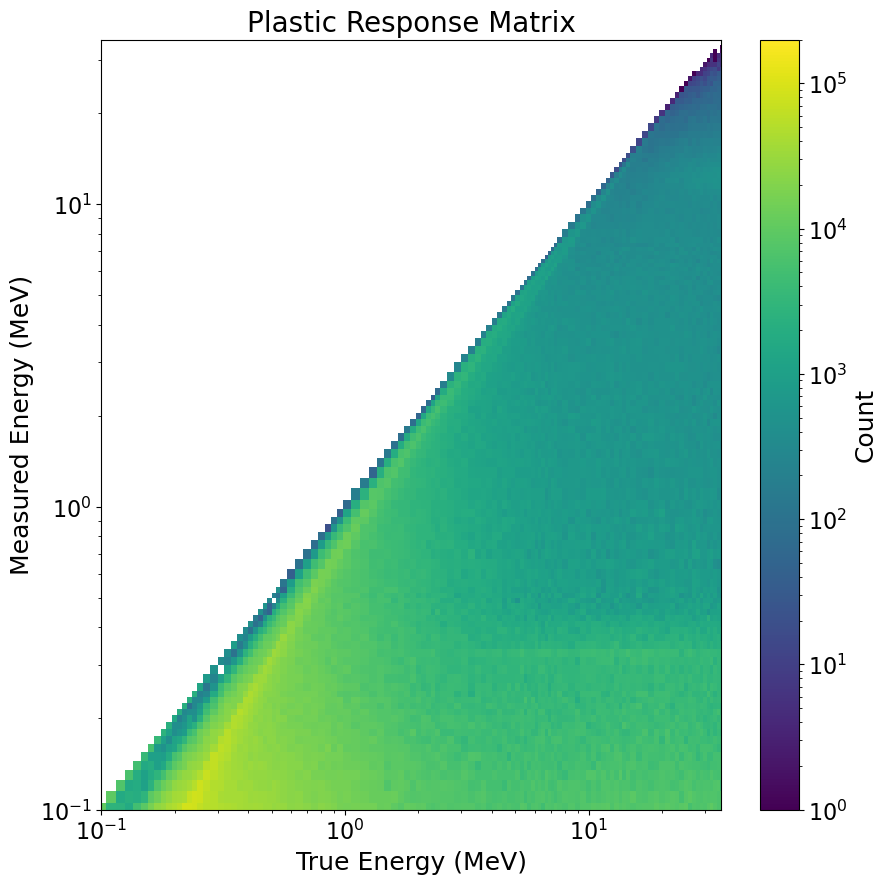

In [9]:
plt.figure(figsize=(10,10))
LgPl_matrix = np.array(LgPl_matrix)
plt.pcolormesh(sequential_input_energies, binCenters, (LgPl_matrix/binWidths).T,
               shading=shading,cmap=cmap_color, norm=LogNorm())
cb = plt.colorbar()
cb.ax.tick_params(labelsize=16)
cb.set_label(label='Count',size=18)
plt.xlim(.1,35)
plt.ylim(.1,35)
plt.xscale('log')
plt.yscale('log')
plt.title('Plastic Response Matrix',fontsize=20)
plt.xlabel('True Energy (MeV)',fontsize=18)
plt.ylabel('Measured Energy (MeV)',fontsize=18)
plt.tick_params(labelsize=16)